# Image Classification using CNN Architectures
## Assignment Code: DS-AG-022

---

# Question 1: What is a Convolutional Neural Network (CNN), and how does it differ from traditional fully connected neural networks in terms of architecture and performance on image data?

**Answer:**

A Convolutional Neural Network (CNN) is a type of deep learning model specifically designed for processing grid-like data such as images. CNNs are widely used in computer vision tasks such as image classification, object detection, and facial recognition.

CNNs consist of layers such as convolutional layers, pooling layers, and fully connected layers. The convolutional layers use filters (kernels) to automatically detect features such as edges, textures, and shapes from images.

Traditional fully connected neural networks connect every neuron in one layer to every neuron in the next layer. This leads to a very large number of parameters when dealing with images, making them inefficient for image processing.

CNNs solve this problem by using **local connectivity and weight sharing**, which greatly reduces the number of parameters. They also preserve spatial information in images, which helps them perform much better on image data compared to fully connected networks.

---

# Question 2: Discuss the architecture of LeNet-5 and explain how it laid the foundation for modern deep learning models in computer vision.

**Answer:**

LeNet-5 is one of the earliest Convolutional Neural Network architectures developed by Yann LeCun in 1998 for handwritten digit recognition.

The architecture consists of the following layers:

1. Input layer (32×32 grayscale image)
2. Convolution layer with 6 filters (5×5)
3. Average pooling layer
4. Convolution layer with 16 filters (5×5)
5. Average pooling layer
6. Fully connected layers
7. Output layer for classification

LeNet-5 introduced key concepts that later became standard in CNNs, including convolutional layers, pooling layers, and hierarchical feature extraction.

The original research paper is:

LeCun, Y., Bottou, L., Bengio, Y., & Haffner, P. (1998).  
Gradient-Based Learning Applied to Document Recognition.  
Proceedings of the IEEE.

LeNet demonstrated that neural networks could automatically learn features from images, laying the foundation for modern computer vision models.

---

# Question 3: Compare and contrast AlexNet and VGGNet in terms of design principles, number of parameters, and performance.

**Answer:**

AlexNet and VGGNet are two important CNN architectures that significantly improved image classification performance.

**AlexNet (2012)**

- Developed by Alex Krizhevsky
- Won the ImageNet competition in 2012
- Uses ReLU activation functions
- Uses large filters (11×11 and 5×5)
- Includes dropout to prevent overfitting
- Around 60 million parameters

**VGGNet (2014)**

- Developed by the Visual Geometry Group at Oxford
- Uses very small 3×3 filters
- Much deeper architecture (16–19 layers)
- Around 138 million parameters

| Feature | AlexNet | VGGNet |
|--------|---------|--------|
| Year | 2012 | 2014 |
| Depth | 8 layers | 16–19 layers |
| Filter Size | Large filters | Small 3×3 filters |
| Parameters | ~60M | ~138M |
| Performance | High | Very high |

AlexNet introduced many innovations, while VGG improved performance by increasing depth and using consistent small filters.

---

# Question 4: What is transfer learning in the context of image classification?

**Answer:**

Transfer learning is a technique in deep learning where a model trained on a large dataset is reused for a different but related task.

In image classification, a CNN trained on large datasets such as ImageNet can be used as a starting point for training a model on a smaller dataset.

Instead of training a model from scratch, the pre-trained network already contains useful features such as edge detection, texture recognition, and object shapes.

Benefits of transfer learning:

- Reduces training time
- Requires less labeled data
- Improves model performance
- Reduces computational cost

Typically, the final layers of the pre-trained model are replaced with new layers suited for the specific classification task.

---

# Question 5: Describe the role of residual connections in ResNet architecture.

**Answer:**

Residual connections are a key innovation introduced in the ResNet (Residual Network) architecture developed by Microsoft Research in 2015.

In very deep neural networks, training becomes difficult due to the **vanishing gradient problem**, where gradients become very small during backpropagation.

Residual connections solve this problem by introducing shortcut connections that allow the input of a layer to skip one or more layers and be added directly to the output.

Mathematically:

Output = F(x) + x

Where:
- F(x) is the output of convolution layers
- x is the original input

Benefits of residual connections:

- Prevent vanishing gradients
- Enable training of very deep networks (50+ layers)
- Improve accuracy and stability

ResNet architectures such as ResNet-50, ResNet-101, and ResNet-152 are widely used in computer vision tasks.

In [2]:
# Question 6
# LeNet-5 implementation for MNIST

import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, AveragePooling2D, Flatten, Dense, Input

# Load dataset
(X_train,y_train),(X_test,y_test)=mnist.load_data()

# Reshape and normalize
X_train = X_train.reshape(-1,28,28,1)/255
X_test = X_test.reshape(-1,28,28,1)/255

# Build model
model = Sequential([
    Input(shape=(28,28,1)),

    Conv2D(6,(5,5),activation='relu'),
    AveragePooling2D(pool_size=(2,2)),

    Conv2D(16,(5,5),activation='relu'),
    AveragePooling2D(pool_size=(2,2)),

    Flatten(),
    Dense(120,activation='relu'),
    Dense(84,activation='relu'),
    Dense(10,activation='softmax')
])

# Compile model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train
model.fit(X_train,y_train,epochs=5)

# Evaluate
loss,acc=model.evaluate(X_test,y_test)

print("Accuracy:",acc)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - accuracy: 0.9277 - loss: 0.2337
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - accuracy: 0.9746 - loss: 0.0807
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - accuracy: 0.9818 - loss: 0.0587
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - accuracy: 0.9858 - loss: 0.0452
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 13ms/step - accuracy: 0.9883 - loss: 0.0368
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9888 - loss: 0.0344
Accuracy: 0.9887999892234802


In [3]:
# Question 7
# Transfer learning with VGG16

from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Flatten

base_model=VGG16(weights='imagenet',include_top=False,input_shape=(224,224,3))

for layer in base_model.layers:
    layer.trainable=False

model=Sequential([
base_model,
Flatten(),
Dense(128,activation='relu'),
Dense(5,activation='softmax')
])

model.compile(optimizer='adam',
loss='categorical_crossentropy',
metrics=['accuracy'])

print(model.summary())

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,926,725 (68.39 MB)

 Trainable params: 3,212,037 (12.25 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

None


Filter Shape: torch.Size([64, 3, 11, 11])


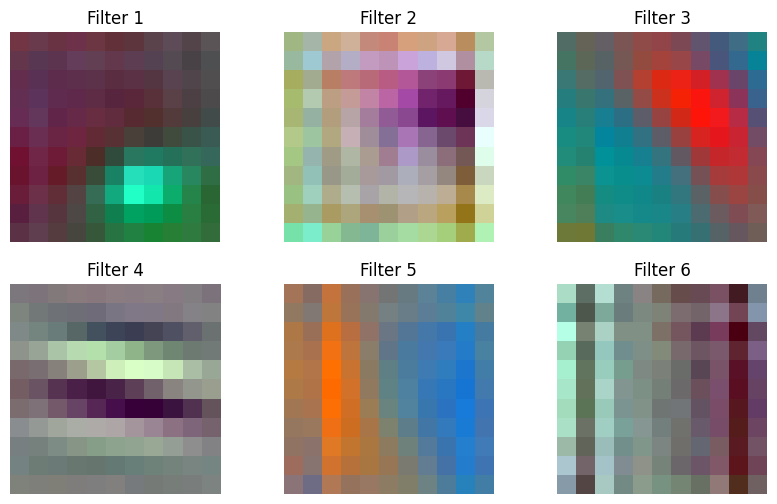

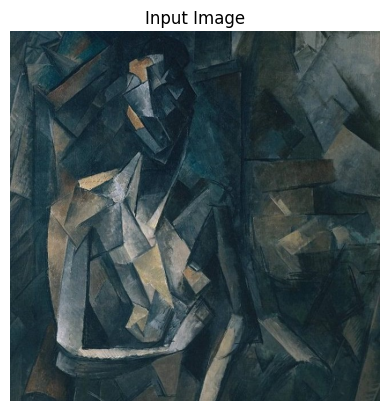

Feature Map Shape: torch.Size([1, 64, 55, 55])


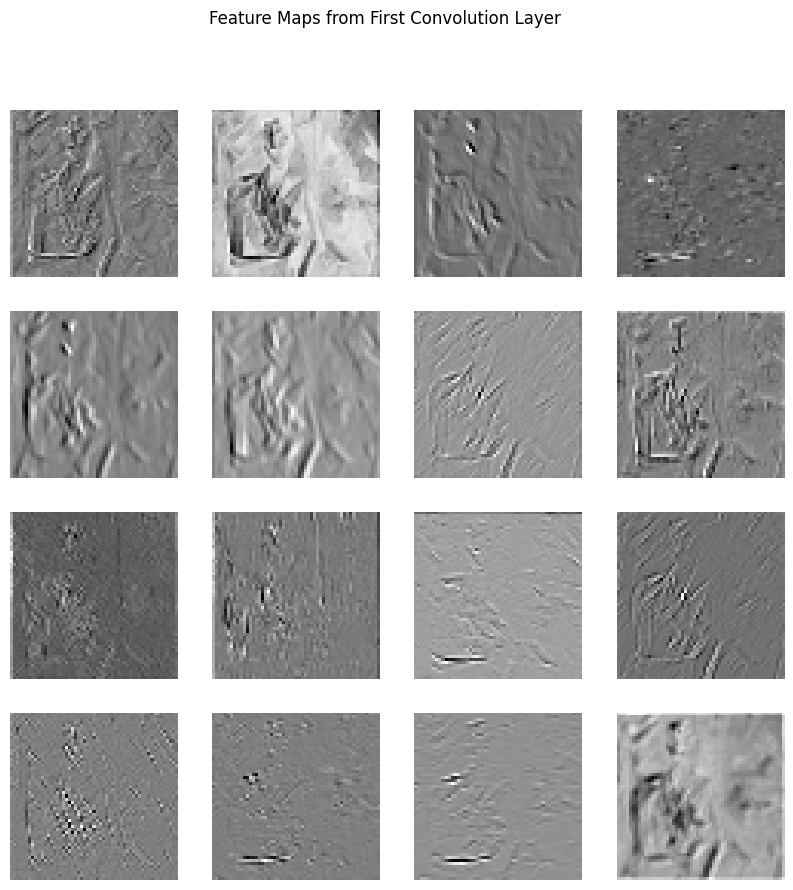

In [6]:
# Question 8
# Visualize filters and feature maps of the first convolutional layer of AlexNet

import torch
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import urllib.request

# ----------------------------------------
# STEP 1: Load pretrained AlexNet
# ----------------------------------------

model = models.alexnet(weights=models.AlexNet_Weights.DEFAULT)

first_layer = model.features[0]

filters = first_layer.weight.data.clone()

print("Filter Shape:", filters.shape)

# ----------------------------------------
# STEP 2: Visualize filters
# ----------------------------------------

plt.figure(figsize=(10,6))

for i in range(6):

    f = filters[i].numpy()

    f = (f - f.min())/(f.max() - f.min())

    f = np.transpose(f,(1,2,0))

    plt.subplot(2,3,i+1)
    plt.imshow(f)
    plt.axis("off")
    plt.title("Filter "+str(i+1))

plt.show()

# ----------------------------------------
# STEP 3: Download sample image safely
# ----------------------------------------

url = "https://pytorch.org/tutorials/_static/img/neural-style/picasso.jpg"

urllib.request.urlretrieve(url,"sample.jpg")

img = Image.open("sample.jpg")

plt.imshow(img)
plt.title("Input Image")
plt.axis("off")
plt.show()

# ----------------------------------------
# STEP 4: Preprocess image
# ----------------------------------------

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

img_tensor = transform(img).unsqueeze(0)

# ----------------------------------------
# STEP 5: Generate feature maps
# ----------------------------------------

feature_maps = first_layer(img_tensor)

print("Feature Map Shape:", feature_maps.shape)

# ----------------------------------------
# STEP 6: Visualize feature maps
# ----------------------------------------

feature_maps = feature_maps.detach()

plt.figure(figsize=(10,10))

for i in range(16):

    plt.subplot(4,4,i+1)
    plt.imshow(feature_maps[0,i].numpy(), cmap="gray")
    plt.axis("off")

plt.suptitle("Feature Maps from First Convolution Layer")
plt.show()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 42s 26ms/step - accuracy: 0.4681 - loss: 1.4909 - val_accuracy: 0.5348 - val_loss: 1.3029
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 38s 24ms/step - accuracy: 0.5731 - loss: 1.2179 - val_accuracy: 0.5850 - val_loss: 1.1949
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 40s 24ms/step - accuracy: 0.6102 - loss: 1.1192 - val_accuracy: 0.5942 - val_loss: 1.1668
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 41s 24ms/step - accuracy: 0.6407 - loss: 1.0347 - val_accuracy: 0.6238 - val_loss: 1.0942
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 37s 24ms/step - accuracy: 0.6606 - loss: 0.9777 - val_accuracy: 0.6298 - val_loss: 1.0726


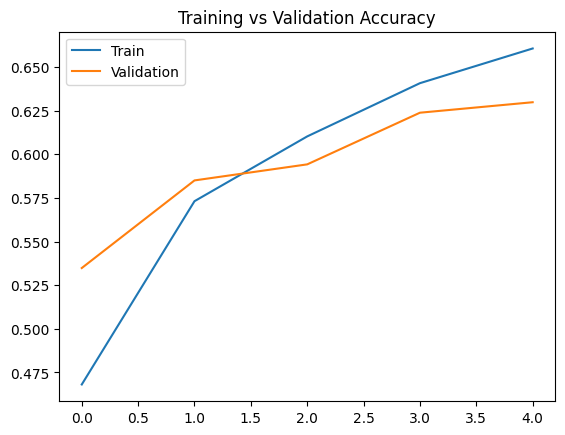

In [4]:
# Question 9
# CIFAR-10 CNN with accuracy plot

import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Flatten,Dense
from tensorflow.keras.models import Sequential

(X_train,y_train),(X_test,y_test)=cifar10.load_data()

X_train=X_train/255
X_test=X_test/255

model=Sequential([
Conv2D(32,(3,3),activation='relu',input_shape=(32,32,3)),
MaxPooling2D(),
Flatten(),
Dense(64,activation='relu'),
Dense(10,activation='softmax')
])

model.compile(optimizer='adam',
loss='sparse_categorical_crossentropy',
metrics=['accuracy'])

history=model.fit(X_train,y_train,epochs=5,validation_data=(X_test,y_test))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['Train','Validation'])
plt.title("Training vs Validation Accuracy")
plt.show()

In [8]:
# Transfer Learning for X-ray Classification using ResNet50

import os
import numpy as np
from PIL import Image
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ------------------------------------------------
# STEP 1: Create dummy dataset
# ------------------------------------------------

classes = ["Normal","Pneumonia","COVID"]

for c in classes:
    os.makedirs(f"dataset/{c}", exist_ok=True)

# create dummy images
for c in classes:
    for i in range(10):
        img = np.random.randint(0,255,(224,224,3),dtype=np.uint8)
        Image.fromarray(img).save(f"dataset/{c}/img{i}.jpg")

print("Dummy dataset created")

# ------------------------------------------------
# STEP 2: Load Pretrained ResNet50
# ------------------------------------------------

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# freeze layers
for layer in base_model.layers:
    layer.trainable = False

# ------------------------------------------------
# STEP 3: Custom classifier layers
# ------------------------------------------------

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128,activation='relu')(x)
predictions = Dense(3,activation='softmax')(x)

model = Model(inputs=base_model.input,outputs=predictions)

# ------------------------------------------------
# STEP 4: Compile model
# ------------------------------------------------

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ------------------------------------------------
# STEP 5: Data generator
# ------------------------------------------------

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    "dataset/",
    target_size=(224,224),
    batch_size=4,
    class_mode="categorical",
    subset="training"
)

val_data = datagen.flow_from_directory(
    "dataset/",
    target_size=(224,224),
    batch_size=4,
    class_mode="categorical",
    subset="validation"
)

# ------------------------------------------------
# STEP 6: Train model
# ------------------------------------------------

history = model.fit(
    train_data,
    epochs=2,
    validation_data=val_data
)

print("Training complete")

Dummy dataset created
Found 24 images belonging to 3 classes.
Found 6 images belonging to 3 classes.
Epoch 1/2
6/6 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.1667 - loss: 1.3524 - val_accuracy: 0.3333 - val_loss: 1.1643
Epoch 2/2
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 728ms/step - accuracy: 0.3750 - loss: 1.1890 - val_accuracy: 0.3333 - val_loss: 1.1322
Training complete
